In [1]:
# Mount Drive and verify environment
from google.colab import drive
drive.mount('/content/drive')

import os
import torch
import numpy as np
import pickle
import matplotlib
import matplotlib.pyplot as plt

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

STGCN_CKPT  = '/content/drive/MyDrive/HRC_Research/checkpoints/stgcn_hri30_70_10_20/best_stgcn_hri30.pt'
CTRGCN_CKPT = '/content/drive/MyDrive/HRC_Research/checkpoints/ctrgcn_hri30_70_10_20/best_ctrgcn_hri30.pt'

STGCN_TEST_DATA  = '/content/drive/MyDrive/HRC_Research/datasets/HRI30/HRI30_70_10_20/stgcn_format/test_data.npy'
STGCN_TEST_LABEL = '/content/drive/MyDrive/HRC_Research/datasets/HRI30/HRI30_70_10_20/stgcn_format/test_label.pkl'
CTRGCN_TEST_NPZ  = '/content/drive/MyDrive/HRC_Research/datasets/HRI30/HRI30_70_10_20/ctrgcn_format/HRI30_CS.npz'

print("\n--- Checkpoint verification ---")
for name, path in [("ST-GCN checkpoint", STGCN_CKPT), ("CTR-GCN checkpoint", CTRGCN_CKPT)]:
    if os.path.exists(path):
        size_mb = os.path.getsize(path) / 1024**2
        print(f"{name}: {size_mb:.1f} MB")
    else:
        print(f"MISSING: {name} at {path}")

print("\n--- Test data verification ---")
for name, path in [("ST-GCN test data", STGCN_TEST_DATA),
                   ("ST-GCN test labels", STGCN_TEST_LABEL),
                   ("CTR-GCN npz", CTRGCN_TEST_NPZ)]:
    if os.path.exists(path):
        size_mb = os.path.getsize(path) / 1024**2
        print(f"{name}: {size_mb:.1f} MB")
    else:
        print(f"MISSING: {name} at {path}")

Mounted at /content/drive
PyTorch version: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4

--- Checkpoint verification ---
ST-GCN checkpoint: 11.9 MB
CTR-GCN checkpoint: 5.8 MB

--- Test data verification ---
ST-GCN test data: 25.2 MB
ST-GCN test labels: 0.0 MB
CTR-GCN npz: 126.2 MB


In [2]:
# Clone repos, patch, and load both models (70/10/20 Weights)
import os
import sys
import torch
import torch.nn as nn
from pathlib import Path

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

STGCN_DIR  = '/content/st-gcn'
CTRGCN_DIR = '/content/CTR-GCN'

if not os.path.exists(STGCN_DIR):
    os.system(f'git clone https://github.com/yysijie/st-gcn.git {STGCN_DIR}')
    print("ST-GCN cloned.")
else:
    print("ST-GCN already present.")

stgcn_io = Path(f'{STGCN_DIR}/torchlight/torchlight/io.py')
text = stgcn_io.read_text()
if 'weights_only=False' not in text:
    text = text.replace(
        'torch.load(weights_path)',
        'torch.load(weights_path, weights_only=False, map_location="cpu")'
    )
    stgcn_io.write_text(text)
    print("ST-GCN torch.load patch applied.")

os.system(f'pip install -e {STGCN_DIR}/torchlight -q')

if not os.path.exists(CTRGCN_DIR):
    os.system(f'git clone https://github.com/Uason-Chen/CTR-GCN.git {CTRGCN_DIR}')
    print("CTR-GCN cloned.")
else:
    print("CTR-GCN already present.")

os.system('pip install -q tensorboardX torchpack fvcore iopath yacs thop')
os.system(f'pip install -e {CTRGCN_DIR}/torchlight -q')

ctrgcn_util = Path(f'{CTRGCN_DIR}/torchlight/torchlight/util.py')
text = ctrgcn_util.read_text()
if 'PaviLogger = None' not in text:
    text = text.replace(
        'from torchpack.runner.hooks import PaviLogger',
        'try:\n    from torchpack.runner.hooks import PaviLogger\nexcept ImportError:\n    PaviLogger = None'
    )
    ctrgcn_util.write_text(text)
    print("CTR-GCN torchpack patch applied.")

print("\nLoading model architectures...")

sys.path.insert(0, STGCN_DIR)
from net.st_gcn import Model as STGCN_Model

stgcn_model = STGCN_Model(
    in_channels=3,
    num_class=30,
    dropout=0.5,
    edge_importance_weighting=True,
    graph_args={'layout': 'ntu-rgb+d', 'strategy': 'spatial'}
)

stgcn_ckpt = torch.load(
    '/content/drive/MyDrive/HRC_Research/checkpoints/stgcn_hri30_70_10_20/best_stgcn_hri30.pt',
    map_location='cpu', weights_only=False
)
stgcn_state = stgcn_ckpt['model_state_dict'] if isinstance(stgcn_ckpt, dict) and 'model_state_dict' in stgcn_ckpt else stgcn_ckpt
stgcn_state = {k[7:] if k.startswith('module.') else k: v for k, v in stgcn_state.items()}
stgcn_model.load_state_dict(stgcn_state, strict=True)
stgcn_model = stgcn_model.to(device)
stgcn_model.eval()
print("ST-GCN loaded (30 classes) - 70/10/20 Weights ✓")

sys.path.insert(0, CTRGCN_DIR)
from model.ctrgcn import Model as CTRGCN_Model

ctrgcn_model = CTRGCN_Model(
    num_class=30,
    num_point=25,
    num_person=1,
    graph='graph.ntu_rgb_d.Graph',
    graph_args={'labeling_mode': 'spatial'}
)

ctrgcn_ckpt = torch.load(
    '/content/drive/MyDrive/HRC_Research/checkpoints/ctrgcn_hri30_70_10_20/best_ctrgcn_hri30.pt',
    map_location='cpu', weights_only=False
)
ctrgcn_state = ctrgcn_ckpt['model_state_dict'] if isinstance(ctrgcn_ckpt, dict) and 'model_state_dict' in ctrgcn_ckpt else ctrgcn_ckpt
ctrgcn_state = {k[7:] if k.startswith('module.') else k: v for k, v in ctrgcn_state.items()}
ctrgcn_model.load_state_dict(ctrgcn_state, strict=True)
ctrgcn_model = ctrgcn_model.to(device)
ctrgcn_model.eval()
print("CTR-GCN loaded (30 classes) - 70/10/20 Weights ✓")

print("\n[PASS] Both NEW models ready. Proceed to Cell 3.")

Using device: cuda
ST-GCN cloned.
ST-GCN torch.load patch applied.
CTR-GCN cloned.
CTR-GCN torchpack patch applied.

Loading model architectures...
ST-GCN loaded (30 classes) - 70/10/20 Weights ✓
CTR-GCN loaded (30 classes) - 70/10/20 Weights ✓

[PASS] Both NEW models ready. Proceed to Cell 3.


In [3]:
# Load test data for both models
import numpy as np
import pickle
import torch

# UPDATED PATHS
STGCN_TEST_DATA = '/content/drive/MyDrive/HRC_Research/datasets/HRI30/HRI30_70_10_20/stgcn_format/test_data.npy'
STGCN_TEST_LABEL = '/content/drive/MyDrive/HRC_Research/datasets/HRI30/HRI30_70_10_20/stgcn_format/test_label.pkl'

stgcn_test_data = np.load(STGCN_TEST_DATA)

with open(STGCN_TEST_LABEL, 'rb') as f:
    _, y_test = pickle.load(f)

stgcn_test_labels = np.array(y_test)

print(f"ST-GCN test data shape: {stgcn_test_data.shape}")
print(f"ST-GCN test labels shape: {stgcn_test_labels.shape}")
print(f"ST-GCN label range: {stgcn_test_labels.min()} to {stgcn_test_labels.max()}")

# UPDATED PATH
CTRGCN_NPZ = '/content/drive/MyDrive/HRC_Research/datasets/HRI30/HRI30_70_10_20/ctrgcn_format/HRI30_CS.npz'

npz = np.load(CTRGCN_NPZ)
print(f"\nCTR-GCN npz keys: {list(npz.keys())}")

ctrgcn_test_data = npz['x_test']
ctrgcn_test_labels = npz['y_test']

print(f"CTR-GCN test data shape: {ctrgcn_test_data.shape}")
print(f"CTR-GCN test labels shape: {ctrgcn_test_labels.shape}")
print(f"CTR-GCN label range: {ctrgcn_test_labels.min()} to {ctrgcn_test_labels.max()}")

# Verification
assert stgcn_test_data.shape[0] == ctrgcn_test_data.shape[0], (
    f"Sample count mismatch: ST-GCN={stgcn_test_data.shape[0]}, CTR-GCN={ctrgcn_test_data.shape[0]}"
)

assert (stgcn_test_labels == ctrgcn_test_labels).all(), (
    "Label mismatch between ST-GCN and CTR-GCN test sets!"
)

print(f"\n[PASS] Both test sets loaded: {stgcn_test_data.shape[0]} samples, 30 classes")
print("[PASS] Labels are identical between both formats")

ST-GCN test data shape: (588, 3, 150, 25, 1)
ST-GCN test labels shape: (588,)
ST-GCN label range: 0 to 29

CTR-GCN npz keys: ['x_train', 'y_train', 'x_val', 'y_val', 'x_test', 'y_test']
CTR-GCN test data shape: (588, 3, 150, 25, 1)
CTR-GCN test labels shape: (588,)
CTR-GCN label range: 0 to 29

[PASS] Both test sets loaded: 588 samples, 30 classes
[PASS] Labels are identical between both formats


In [4]:
# Occlusion simulation benchmark
import torch
import numpy as np
import csv
import os

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def apply_occlusion(data_np, occlusion_rate, seed=None):
    if occlusion_rate == 0.0:
        return data_np.copy()
    if seed is not None:
        np.random.seed(seed)
    data_out = data_np.copy()
    num_joints = data_out.shape[3]
    num_to_zero = max(1, int(round(num_joints * occlusion_rate)))
    joints_to_zero = np.random.choice(num_joints, num_to_zero, replace=False)
    data_out[:, :, :, joints_to_zero, :] = 0.0
    return data_out

def run_inference(model, data_np, labels_np, batch_size=64):
    model.eval()
    all_preds = []
    N = data_np.shape[0]
    with torch.no_grad():
        for start in range(0, N, batch_size):
            end = min(start + batch_size, N)
            batch = torch.tensor(data_np[start:end], dtype=torch.float32).to(device)
            output = model(batch)
            preds = output.argmax(dim=1).cpu().numpy()
            all_preds.append(preds)
    all_preds = np.concatenate(all_preds)
    correct = (all_preds == labels_np).sum()
    accuracy = 100.0 * correct / N
    return accuracy

# N=30 TRIALS
OCCLUSION_RATES = [0.0, 0.10, 0.20, 0.30, 0.50]
NUM_TRIALS = 30
results = []

print("=" * 65)
print("PHASE 3 — OCCLUSION SIMULATION BENCHMARK (N=30 TRIALS)")
print("=" * 65)
print(f"Test samples: {stgcn_test_data.shape[0]}")
print(f"Occlusion rates: {[f'{r*100:.0f}%' for r in OCCLUSION_RATES]}")
print(f"Trials per rate: {NUM_TRIALS} (1 trial at 0%)")
print("=" * 65)

for rate in OCCLUSION_RATES:
    rate_label = f"{int(rate * 100)}%"
    n_trials = 1 if rate == 0.0 else NUM_TRIALS
    print(f"\n--- Occlusion rate: {rate_label} ({n_trials} trial(s)) ---")

    stgcn_accs  = []
    ctrgcn_accs = []

    for trial in range(n_trials):
        seed = 42 + trial
        st_corrupted  = apply_occlusion(stgcn_test_data,  rate, seed=seed)
        ctr_corrupted = apply_occlusion(ctrgcn_test_data, rate, seed=seed)

        st_acc = run_inference(stgcn_model, st_corrupted, stgcn_test_labels)
        stgcn_accs.append(st_acc)

        ctr_acc = run_inference(ctrgcn_model, ctr_corrupted, ctrgcn_test_labels)
        ctrgcn_accs.append(ctr_acc)

        if trial % 10 == 0:
            print(f"  Trial {trial+1:2d}: ST-GCN = {st_acc:.2f}%  |  CTR-GCN = {ctr_acc:.2f}%")

    st_mean  = float(np.mean(stgcn_accs))
    ctr_mean = float(np.mean(ctrgcn_accs))
    st_std   = float(np.std(stgcn_accs))
    ctr_std  = float(np.std(ctrgcn_accs))

    print(f"  → Mean: ST-GCN = {st_mean:.2f}% (±{st_std:.2f})  |  CTR-GCN = {ctr_mean:.2f}% (±{ctr_std:.2f})")

    results.append({
        'occlusion_rate': rate_label,
        'stgcn_accs': stgcn_accs,
        'ctrgcn_accs': ctrgcn_accs,
        'stgcn_mean': st_mean,
        'ctrgcn_mean': ctr_mean,
        'stgcn_std': st_std,
        'ctrgcn_std': ctr_std
    })

print("\n" + "=" * 65)
print("BENCHMARK COMPLETE")
print("=" * 65)

OUTPUT_DIR = '/content/drive/MyDrive/HRC_Research/results/occlusion_benchmark'
os.makedirs(OUTPUT_DIR, exist_ok=True)
CSV_PATH = os.path.join(OUTPUT_DIR, 'occlusion_results_n30_70_10_20.csv')

with open(CSV_PATH, 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow([
        'occlusion_rate',
        'stgcn_mean', 'stgcn_std',
        'ctrgcn_mean', 'ctrgcn_std',
        'stgcn_accs', 'ctrgcn_accs'
    ])
    for r in results:
        writer.writerow([
            r['occlusion_rate'],
            f"{r['stgcn_mean']:.4f}", f"{r['stgcn_std']:.4f}",
            f"{r['ctrgcn_mean']:.4f}", f"{r['ctrgcn_std']:.4f}",
            r['stgcn_accs'], r['ctrgcn_accs']
        ])

csv_size_kb = os.path.getsize(CSV_PATH) / 1024
print(f"\nCSV saved to Drive: {CSV_PATH}")
print(f"   File size: {csv_size_kb:.2f} KB")

PHASE 3 — OCCLUSION SIMULATION BENCHMARK (N=30 TRIALS)
Test samples: 588
Occlusion rates: ['0%', '10%', '20%', '30%', '50%']
Trials per rate: 30 (1 trial at 0%)

--- Occlusion rate: 0% (1 trial(s)) ---
  Trial  1: ST-GCN = 55.27%  |  CTR-GCN = 67.69%
  → Mean: ST-GCN = 55.27% (±0.00)  |  CTR-GCN = 67.69% (±0.00)

--- Occlusion rate: 10% (30 trial(s)) ---
  Trial  1: ST-GCN = 51.87%  |  CTR-GCN = 53.57%
  Trial 11: ST-GCN = 35.71%  |  CTR-GCN = 52.55%
  Trial 21: ST-GCN = 54.59%  |  CTR-GCN = 49.83%
  → Mean: ST-GCN = 43.55% (±7.30)  |  CTR-GCN = 50.90% (±5.86)

--- Occlusion rate: 20% (30 trial(s)) ---
  Trial  1: ST-GCN = 35.54%  |  CTR-GCN = 29.93%
  Trial 11: ST-GCN = 28.74%  |  CTR-GCN = 39.29%
  Trial 21: ST-GCN = 38.95%  |  CTR-GCN = 37.41%
  → Mean: ST-GCN = 29.61% (±8.41)  |  CTR-GCN = 33.88% (±5.89)

--- Occlusion rate: 30% (30 trial(s)) ---
  Trial  1: ST-GCN = 40.31%  |  CTR-GCN = 19.05%
  Trial 11: ST-GCN = 17.69%  |  CTR-GCN = 23.98%
  Trial 21: ST-GCN = 18.54%  |  CTR-GCN

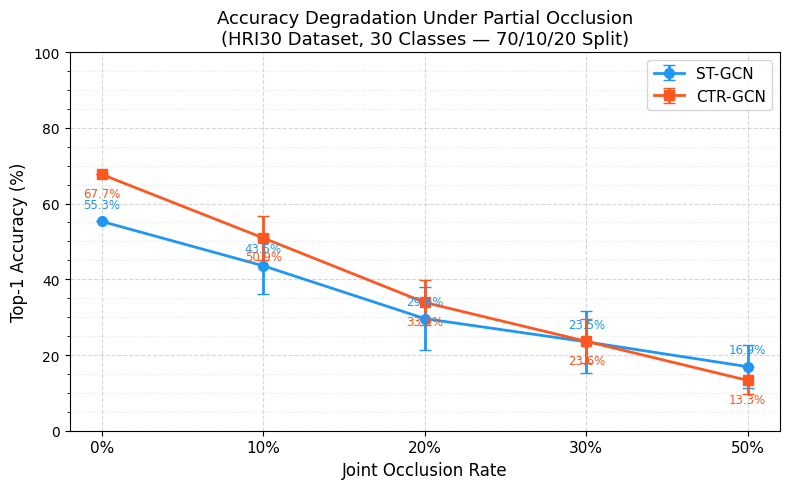


Plot saved to Drive: /content/drive/MyDrive/HRC_Research/results/occlusion_benchmark/accuracy_degradation_curves_70_10_20.png
   File size: 96.0 KB


In [5]:
# Plot accuracy degradation curves and save to Drive
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import os

occlusion_labels = [r['occlusion_rate'] for r in results]
stgcn_means  = [r['stgcn_mean']  for r in results]
ctrgcn_means = [r['ctrgcn_mean'] for r in results]
stgcn_stds   = [r['stgcn_std']   for r in results]
ctrgcn_stds  = [r['ctrgcn_std']  for r in results]

x = list(range(len(occlusion_labels)))

fig, ax = plt.subplots(figsize=(8, 5))

ax.errorbar(x, stgcn_means, yerr=stgcn_stds,
            label='ST-GCN', marker='o', color='#2196F3',
            linewidth=2, markersize=7, capsize=4)

ax.errorbar(x, ctrgcn_means, yerr=ctrgcn_stds,
            label='CTR-GCN', marker='s', color='#FF5722',
            linewidth=2, markersize=7, capsize=4)

for i, (st, ctr) in enumerate(zip(stgcn_means, ctrgcn_means)):
    ax.annotate(f'{st:.1f}%', xy=(i, st),
                xytext=(0, 10), textcoords='offset points',
                ha='center', fontsize=8.5, color='#2196F3')
    ax.annotate(f'{ctr:.1f}%', xy=(i, ctr),
                xytext=(0, -16), textcoords='offset points',
                ha='center', fontsize=8.5, color='#FF5722')

ax.set_xticks(x)
ax.set_xticklabels(occlusion_labels, fontsize=11)
ax.set_xlabel('Joint Occlusion Rate', fontsize=12)
ax.set_ylabel('Top-1 Accuracy (%)', fontsize=12)
ax.set_title('Accuracy Degradation Under Partial Occlusion\n(HRI30 Dataset, 30 Classes — 70/10/20 Split)', fontsize=13)
ax.legend(fontsize=11, loc='upper right')
ax.yaxis.set_minor_locator(mticker.AutoMinorLocator())
ax.grid(True, which='major', linestyle='--', alpha=0.5)
ax.grid(True, which='minor', linestyle=':', alpha=0.3)

min_val = min(min(stgcn_means), min(ctrgcn_means))
ax.set_ylim(max(0, min_val - 15), 100)

plt.tight_layout()

OUTPUT_DIR = '/content/drive/MyDrive/HRC_Research/results/occlusion_benchmark'
os.makedirs(OUTPUT_DIR, exist_ok=True)
# NEW FILENAME
PLOT_PATH = os.path.join(OUTPUT_DIR, 'accuracy_degradation_curves_70_10_20.png')

plt.savefig(PLOT_PATH, dpi=150, bbox_inches='tight')
plt.show()

plot_size_kb = os.path.getsize(PLOT_PATH) / 1024
print(f"\nPlot saved to Drive: {PLOT_PATH}")
print(f"   File size: {plot_size_kb:.1f} KB")

In [6]:
# Print a clean summary table to console
import pandas as pd
import os

CSV_PATH = '/content/drive/MyDrive/HRC_Research/results/occlusion_benchmark/occlusion_results_n30_70_10_20.csv'

if os.path.exists(CSV_PATH):
    df = pd.read_csv(CSV_PATH)
    print("\n" + "=" * 55)
    print("FINAL SUMMARY TABLE (70/10/20 Split)")
    print("=" * 55)
    print(f"{'Occlusion':<12} {'ST-GCN Mean':>14} {'CTR-GCN Mean':>14} {'Gap':>8}")
    print("-" * 55)
    for _, row in df.iterrows():
        gap = float(row['ctrgcn_mean']) - float(row['stgcn_mean'])
        print(f"{str(row['occlusion_rate']):<12} {float(row['stgcn_mean']):>13.2f}%  {float(row['ctrgcn_mean']):>13.2f}%  {gap:>+7.2f}pp")
    print("=" * 55)
else:
    print(f"CSV not found at {CSV_PATH}. Make sure Cell 4 ran successfully.")


FINAL SUMMARY TABLE (70/10/20 Split)
Occlusion       ST-GCN Mean   CTR-GCN Mean      Gap
-------------------------------------------------------
0%                   55.27%          67.69%   +12.41pp
10%                  43.55%          50.90%    +7.35pp
20%                  29.61%          33.88%    +4.27pp
30%                  23.48%          23.61%    +0.13pp
50%                  16.92%          13.29%    -3.62pp
